# Comparison of two group means

- Use Stan/cmdstanpy
- You are encouraged to use any AI agent, but you must understand the core idea of the python program provided by the agent.

1. Run the simulation experiment with N1 and N2 as written in the Exercise.
2. Change N1=300, N2=200, and run the same simulation experiment.
3. Compare the two results and provide your analysis and explanation.

![Exercise 4.5.1](./matsuura-exercise4.5.1.png)

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [6]:
# seed for reproducibility
np.random.seed(123)  # set.seed(123)
N1 = 30
mu1 = 0
sigma1 = 5
N2 = 20
mu2 = 1
sigma2 = 4
Y1 = np.random.normal(loc=mu1, scale=sigma1, size=N1) # Y1 ~ N(0, 5^2)
Y2 = np.random.normal(loc=mu2, scale=sigma2, size=N2) # Y2 ~ N(1, 4^2)

### (1) Visualize the data from the two groups

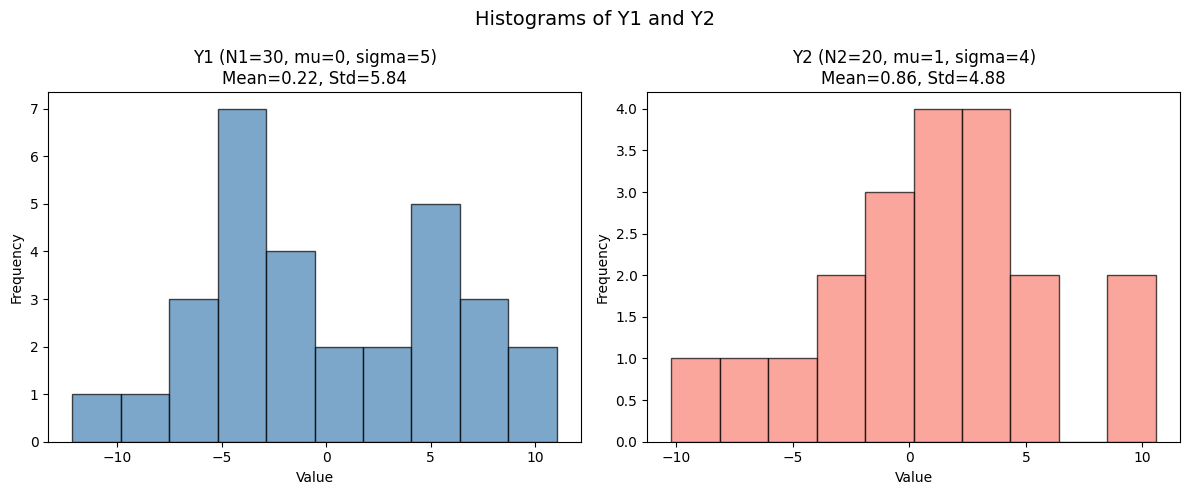

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(Y1, bins=10, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title(f'Y1 (N1={N1}, mu={mu1}, sigma={sigma1})\nMean={Y1.mean():.2f}, Std={Y1.std():.2f}')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')

axes[1].hist(Y2, bins=10, color='salmon', edgecolor='black', alpha=0.7)
axes[1].set_title(f'Y2 (N2={N2}, mu={mu2}, sigma={sigma2})\nMean={Y2.mean():.2f}, Std={Y2.std():.2f}')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Frequency')

plt.suptitle('Histograms of Y1 and Y2', fontsize=14)
plt.tight_layout()  
plt.show()      

### (2) Write a model formula with the assumption that these two groups have the same SD.
- This corresponds to the Student's t-test

Y1 ~ Normal(mu1, sigma)

Y2 ~ Normal(mu2, sigma)

In [ ]:
stan_model_code = """
data {
    int<lower=0> N1;
    int<lower=0> N2;
    vector[N1] Y1;
    vector[N2] Y2;
}

parameters {
    real mu1;
    real mu2;
    real<lower=0> sigma;  // shared SD
}

model {
    // priors
    mu1 ~ normal(0, 100);
    mu2 ~ normal(0, 100);
    sigma ~ cauchy(0, 10);

    // likelihood
    Y1 ~ normal(mu1, sigma);
    Y2 ~ normal(mu2, sigma);
}

generated quantities {
    real diff = mu2 - mu1;  // difference of means
}
"""

# Save the model to a file
with open('compare_means_equal_std.stan', 'w') as f:
    f.write(stan_model_code)

print("Stan model saved to compare_means_equal_std.stan")
print(stan_model_code)

### (3) Estimate the parameters using 'cmdstanpy' using the Stan model code

In [ ]:
# 이 셀에 모델링과 추론 코드를 작성하세요.


### (4) Compute Prob[mu1 < mu2] from the obtained MCMC draws using `cmdstanpy`

In [ ]:
# 이 셀에 모델링과 추론 코드를 작성하세요.
# 추론 결과를 그림으로 보여주세요.
# 새로운 셀을 아래에 추가하여 사용해도 됩니다.

### (5) Write a model formula with the assumption that the two SDs are different, and compute Prob[mu1 < mu2]

- Assumption: $\sigma_1 \neq \sigma_2$

In [ ]:
# 이 셀에 모델링과 추론 코드를 작성하세요.


---
# N1=300, N2=200
---

아래에 필요한 python 프로그램을 작성하여 실험하시오.

---
# 데이터 갯수가 다른 두 경우에 대한 추론 결과 비교 해석
---

End.